Ноутбук воспроизводит сопроводительные графики и таблицы к репорту - метрики на полном тест-сплите, реконструкции. Полный текст отчёта в [REPORT.md](REPORT.md).

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate
from huggingface_hub import hf_hub_download

sys.path.insert(0, ".")
from src.utils.image_utils import normalize_minmax, roi_crop

device = "cuda" if torch.cuda.is_available() else "cpu"
CONFIG_DIR = str(Path("src/configs").resolve())
print("device:", device)

/home/tiom4eg/prog/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## Количественное сравнение

Метрики на полном тест-сплите DigiCam (1500 изображений), на ROI, по-картиночное усреднение. `sec/img` - время прямого прохода на одной T4.

,PSNR,SSIM,MSE,LPIPS,sec/img
method,,,,,
FISTA,10.982,0.265,0.103,0.771,0.245
ADMM-100,11.686,0.279,0.086,0.752,0.952
ADMM-100 + SR,11.390,0.299,0.092,0.754,1.129
Unrolled Le-ADMM-20,12.232,0.283,0.072,0.776,0.192
Modular Le-ADMM-5 (pre),13.542,0.322,0.051,0.786,0.102
Modular Le-ADMM-5 (post),14.734,0.388,0.039,0.740,0.103
"Modular Le-ADMM-5 (pre+post, 12 epochs)",16.024,0.386,0.030,0.573,0.105
Modular Le-ADMM-5 (pre+post + fine-tune),17.529,0.465,0.022,0.635,0.105


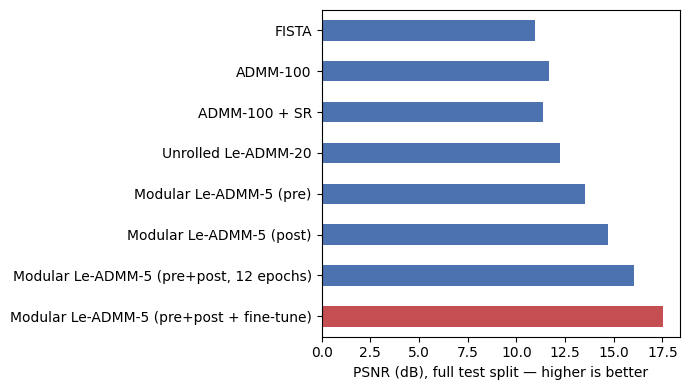

In [5]:
res = json.load(open("eval_results.json"))
ORDER = ["fista", "admm100", "admm100_sr", "leadmm20", "modular_pre", "modular_post", "modular_prepost_12ep", "modular_prepost"]
NAMES = {
    "fista": "FISTA",
    "admm100": "ADMM-100",
    "admm100_sr": "ADMM-100 + SR",
    "leadmm20": "Unrolled Le-ADMM-20",
    "modular_pre": "Modular Le-ADMM-5 (pre)",
    "modular_post": "Modular Le-ADMM-5 (post)",
    "modular_prepost_12ep": "Modular Le-ADMM-5 (pre+post, 12 epochs)",
    "modular_prepost": "Modular Le-ADMM-5 (pre+post + fine-tune)",
}
rows = [[NAMES[k], res[k]["PSNR"], res[k]["SSIM"], res[k]["MSE"],
         res[k]["LPIPS"], res[k]["sec_per_image"]] for k in ORDER]
df = pd.DataFrame(rows, columns=["method", "PSNR", "SSIM", "MSE", "LPIPS", "sec/img"]).set_index("method")
display(df.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4c72b0"] * (len(ORDER) - 1) + ["#c44e52"]
df["PSNR"].plot.barh(ax=ax, color=colors)
ax.invert_yaxis()
ax.set_xlabel("PSNR (dB), full test split — higher is better")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Качественное сравнение

Реконструкции методов на одних и тех же тестовых сэмплах, по возрастанию качества слева направо. Чекпойнты тянутся с HuggingFace, сэмплы строятся из тест-сплита (первый запуск скачает данные и веса).

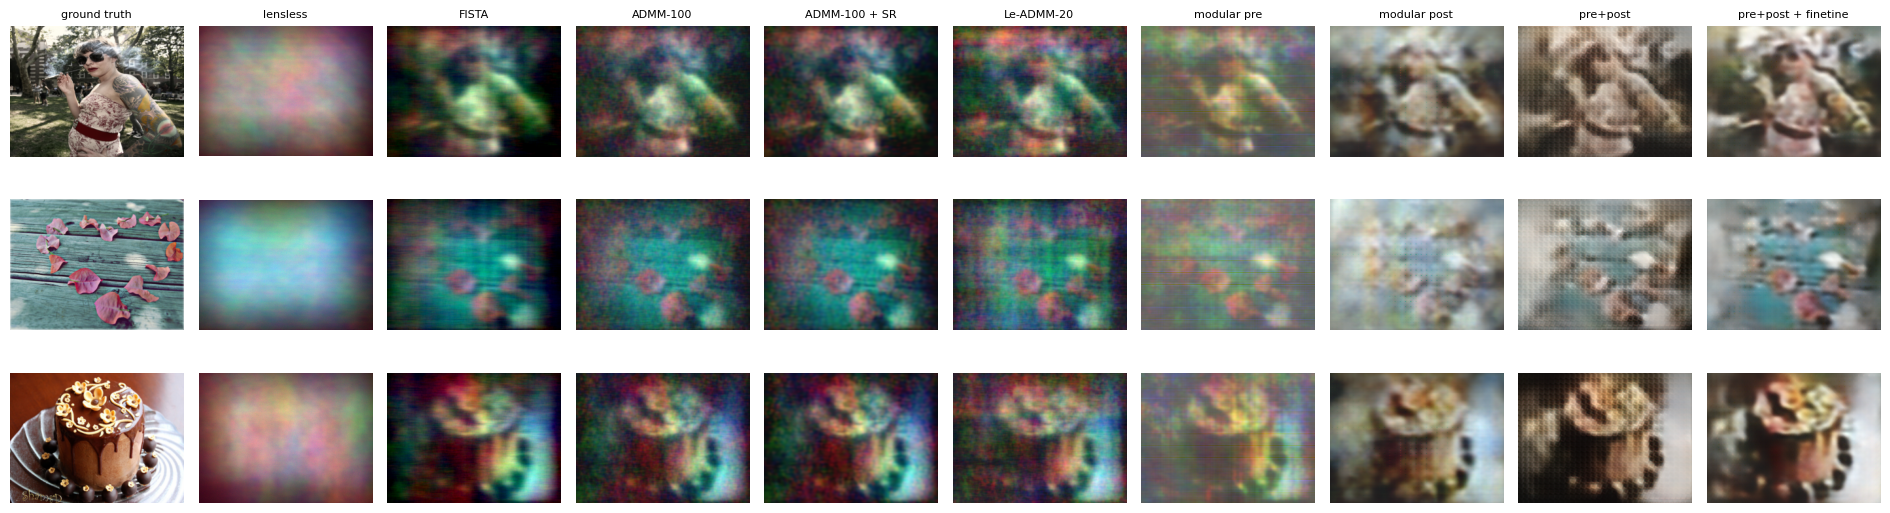

In [8]:
DATA_DIR = Path("data/demo_dataset")
if not (DATA_DIR / "lensless").exists():
    import subprocess
    subprocess.run([sys.executable, "scripts/make_demo_dir.py", "--n", "3",
                    "--out", str(DATA_DIR)], check=True)

from src.datasets import CustomDirDataset

ds = CustomDirDataset(data_dir=str(DATA_DIR))
K = min(3, len(ds))
samples = [ds[i] for i in range(K)]

EP12 = "MHDCSM/lensless-modular_prepost_20260609_003122"
METHOD_SPEC = [
    ("FISTA", "fista", None, None),
    ("ADMM-100", "admm100", None, None),
    ("ADMM-100 + SR", "admm100_sr", None, None),
    ("Le-ADMM-20", "leadmm20", "MHDCSM/lensless-leadmm20_20260609_193725", "model_best.pth"),
    ("modular pre", "modular_pre", "MHDCSM/lensless-modular_pre_20260610_100629", "model_best.pth"),
    ("modular post", "modular_post", "MHDCSM/lensless-modular_post_20260610_035523", "model_best.pth"),
    ("pre+post", "modular_prepost", EP12, "checkpoint-epoch12.pth"),
    ("pre+post + finetine", "modular_prepost", "MHDCSM/lensless-modular_prepost_ft_20260609_190232", "model_best.pth"),
]


def build_model(cfg_name, repo, filename):
    GlobalHydra.instance().clear()
    with initialize_config_dir(version_base=None, config_dir=CONFIG_DIR):
        cfg = compose(config_name="inference", overrides=[f"model={cfg_name}"])
    model = instantiate(cfg.model).to(device).eval()
    if repo:
        ckpt = torch.load(hf_hub_download(repo_id=repo, filename=filename),
                          map_location=device, weights_only=False)
        model.load_state_dict(ckpt["state_dict"] if ckpt.get("state_dict") is not None else ckpt)
    return model


@torch.no_grad()
def reconstruct(model, sample):
    out = model(lensless=sample["lensless"].unsqueeze(0).to(device),
                psf=sample["psf"].unsqueeze(0).to(device))["recon"]
    return normalize_minmax(roi_crop(out)).clamp(0, 1)[0].cpu().permute(1, 2, 0).numpy()


recons = []
for _, cfg_name, repo, filename in METHOD_SPEC:
    model = build_model(cfg_name, repo, filename)
    recons.append([reconstruct(model, s) for s in samples])
    del model
    if device == "cuda":
        torch.cuda.empty_cache()

cols = ["ground truth", "lensless"] + [t for t, _, _, _ in METHOD_SPEC]
fig, axes = plt.subplots(K, len(cols), figsize=(1.9 * len(cols), 1.9 * K))
for i, s in enumerate(samples):
    gt = roi_crop(s["lensed"].unsqueeze(0)).clamp(0, 1)[0].permute(1, 2, 0).numpy()
    lensless = s["lensless"].permute(1, 2, 0).numpy()
    imgs = [gt, lensless] + [recons[mi][i] for mi in range(len(METHOD_SPEC))]
    for j, (img, title) in enumerate(zip(imgs, cols)):
        ax = axes[i, j] if K > 1 else axes[j]
        ax.imshow(np.clip(img, 0, 1))
        ax.axis("off")
        if i == 0:
            ax.set_title(title, fontsize=8)
plt.tight_layout()
plt.show()